# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

`nf-core/differentialabundance`, using the RNA-seq/DESeq2 profile

---

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [1]:
import pandas as pd

# Load provided Salmon gene-count matrix
counts = pd.read_csv(
    "data/salmon.merged.gene_counts.tsv",
    sep="\t"
)

# Sample columns start after gene_id and gene_name
samples = counts.columns[2:]

# Create samplesheet
samplesheet = pd.DataFrame({
    "sample": samples,
    "Condition": samples.str.replace(
        r"_\d+$",
        "",
        regex=True
    )
})

# Save samplesheet
samplesheet.to_csv(
    "samplesheet.csv",
    index=False
)

print(samplesheet)

        sample Condition
0   Sham_oxy_1  Sham_oxy
1   Sham_oxy_2  Sham_oxy
2   Sham_oxy_3  Sham_oxy
3   Sham_oxy_4  Sham_oxy
4   Sham_Sal_1  Sham_Sal
5   Sham_Sal_2  Sham_Sal
6   Sham_Sal_3  Sham_Sal
7   Sham_Sal_4  Sham_Sal
8    SNI_oxy_1   SNI_oxy
9    SNI_oxy_2   SNI_oxy
10   SNI_oxy_3   SNI_oxy
11   SNI_oxy_4   SNI_oxy
12   SNI_Sal_1   SNI_Sal
13   SNI_Sal_2   SNI_Sal
14   SNI_Sal_3   SNI_Sal
15   SNI_Sal_4   SNI_Sal


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [2]:
!nextflow run nf-core/differentialabundance \
    -r 2.0.0 \
    -profile rnaseq,docker \
    -params-file paper_params.yaml \
    --genome GRCm38 \
    --input samplesheet.csv \
    --contrasts data/contrasts.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --features_id_col gene_id \
    --features_name_col gene_name \
    --outdir differentialabundance_results \
    -resume


 N E X T F L O W   ~  version 26.04.6

WARN: It appears you have never run this project before -- Option `-resume` is ignored
Launching `https://github.com/nf-core/differentialabundance` [cheesy_hilbert] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : differentialabundance_results
  study_abundance_type        : counts

[base] Abundan

---

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

- `-r 2.0.0`: fixes the pipeline version for reproducibility
- `-profile rnaseq,docker`: uses the RNA-seq/DESeq2 configuration and runs dependencies in Docker containers
- `-params-file paper_params.yaml`: applies settings matching the paper: nominal `p < 0.05`, `|log2FC| ≥ 0.5`, no q-value filtering, and no DESeq2 LFC shrinkage
- `--genome GRCm38`: uses the mouse GRCm38 reference genome and its associated annotation/reference information
- `--input samplesheet.csv`: sample metadata; links each sample to its `Condition`
- `--contrasts data/contrasts.csv`: defines the two comparisons `SNI_oxy vs SNI_Sal` and `Sham_oxy vs Sham_Sal`
- `--matrix data/salmon.merged.gene_counts.tsv`: Salmon gene-count matrix used for differential expression
- `--features_id_col gene_id`: uses `gene_id` as the unique gene identifier
- `--features_name_col gene_name`: uses `gene_name` as the readable gene label
- `--outdir differentialabundance_results`: output directory for the differential-expression analysis
- `-resume`: reuses successfully completed Nextflow steps from a previous run instead of recomputing them

---

What were the outputs of the pipeline?

- **Differential expression results**
    - DESeq2 result tables for both contrasts
    - filtered significant DEGs using the paper-matched thresholds
    - annotated DEG tables
- **Processed expression matrices**
    - `all.normalised_counts.tsv`
    - `all.vst.tsv`
- **Differential expression plots**
    - volcano plots for both comparisons
- **Exploratory/QC plots**
    - boxplot
    - density plot
    - MAD correlation plot
    - 2D and 3D PCA plots
    - sample dendrogram
- **DESeq2 QC**
    - dispersion plots
    - size-factor tables
    - saved DESeq2/R objects and session info
- **Reports and interactive results**
    - HTML differential-abundance report
    - zipped report bundle
    - ShinyNGS app
- **Pipeline metadata**
    - execution reports, timelines and traces
    - parameters
    - software versions
    - pipeline DAG

---

Would you exclude any samples? If yes, which and why?

- no samples would be excluded based on the differential abundance report
- the pipeline’s outlier detection found no outlying samples within the four `Condition` groups
- some samples show separation in the PCA, but this alone is not sufficient evidence for exclusion
- all 16 samples would be retained for the differential expression analysis

---

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

- **Sham_oxy vs Sham_Sal:** **1,205 DEGs**
    - 869 upregulated
    - 336 downregulated
- **SNI_oxy vs SNI_Sal:** **804 DEGs**
    - 178 upregulated
    - 626 downregulated
- **yes, qualitatively:** the results support the paper's finding that oxycodone withdrawal causes substantial transcriptional changes and that these changes differ between sham and nerve-injured mice
- the exact DEG numbers are not reproduced because the analysis pipeline differs from the original study
- the paper used HISAT2 + HTSeq + DESeq2 with a 2x2 factorial design (`SNI + oxycodone + SNI:oxycodone`)
- this analysis uses Salmon-derived gene counts and direct contrasts between the four `Condition` groups
- the same DEG thresholds (`p < 0.05`, `|log2FC| ≥ 0.5`) are used, differences in quantification and statistical modelling lead to different DEG numbers

---

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

- **NAc (nucleus accumbens)**: part of reward and motivation system; involved in reinforcement, pleasure, and drug-related behavior
- **mPFC (medial prefrontal cortex)**: decision-making, emotional regulation, attention, and control of behavior
- **VTA (ventral tegmental area)**: dopamine-producing midbrain region important for reward, motivation, and addiction; sends dopaminergic projections to regions including the NAc and mPFC

---

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

- **not from the anatomical description alone**
- VTA, NAc and mPFC were dissected separately using bilateral tissue punches and processed for RNA-seq
- the Methods do not define a fixed list of genes belonging to each brain region
- region-specific genes/DEGs are determined from the RNA-seq expression data obtained from each tissue
- the exact gene lists can therefore be obtained from the region-specific RNA-seq data
- these data are available in NCBI GEO: GSE223541
- the paper analyzes NAc, mPFC and VTA separately

---

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

- **no, a DEG list alone is not sufficient**
- the paper used Gene Ontology (GO) analysis and Ingenuity Pathway Analysis (IPA) to interpret the biological meaning of the DEGs
- it also identified **predicted upstream regulators** of the transcriptional changes
- canonical pathway analysis highlighted pathways such as CREB signaling, G-protein-coupled receptor signaling and circadian rhythm signaling
- the authors also used RRHO analysis to compare broader transcriptomic patterns between conditions
- therefore, DEGs should be followed by functional, pathway and regulatory analysis to make the results biologically interpretable

---

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

Sham_oxy vs Sham_Sal: 1205
SNI_oxy vs SNI_Sal:   804
Shared DEGs:           104


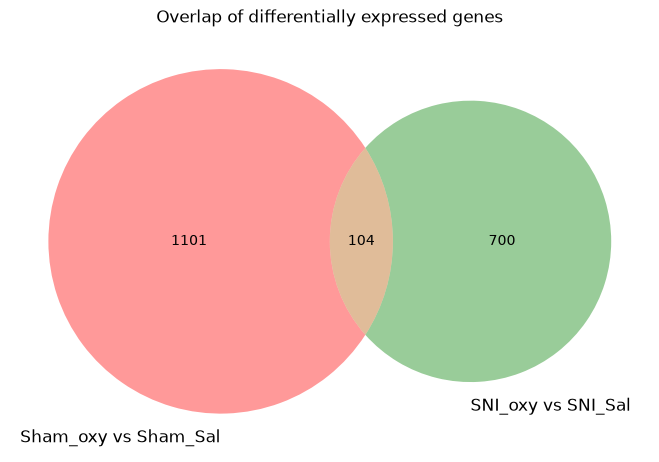

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

base = Path("differentialabundance_results")

# Load DEGs using the paper thresholds: p < 0.05 and |log2FC| >= 0.5
def get_degs(pattern):
    file = next(base.rglob(pattern))
    df = pd.read_csv(file, sep="\t")

    return set(
        df.loc[
            (df["pvalue"] < 0.05) &
            (df["log2FoldChange"].abs() >= 0.5),
            "gene_id"
        ].dropna()
    )

sham = get_degs("*condition_control_treated_test_study.deseq2.results.tsv")
sni = get_degs("*condition_control_treated_study.deseq2.results.tsv")

# DEG overlap
shared = sham & sni

print(f"Sham_oxy vs Sham_Sal: {len(sham)}")
print(f"SNI_oxy vs SNI_Sal:   {len(sni)}")
print(f"Shared DEGs:           {len(shared)}")

# Venn diagram
plt.figure(figsize=(7, 6))
venn2(
    [sham, sni],
    set_labels=("Sham_oxy vs Sham_Sal", "SNI_oxy vs SNI_Sal")
)

plt.title("Overlap of differentially expressed genes")
plt.tight_layout()
plt.savefig("venn_diagram.png", dpi=300, bbox_inches="tight")
plt.show()